In [6]:
import pandas as pd
from holoviews.operation import threshold
from statsmodels.stats.contrast import t_test_multi

churn = pd.read_csv('Bank_Churn.csv')
churn.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## EDA

In [8]:
churn.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


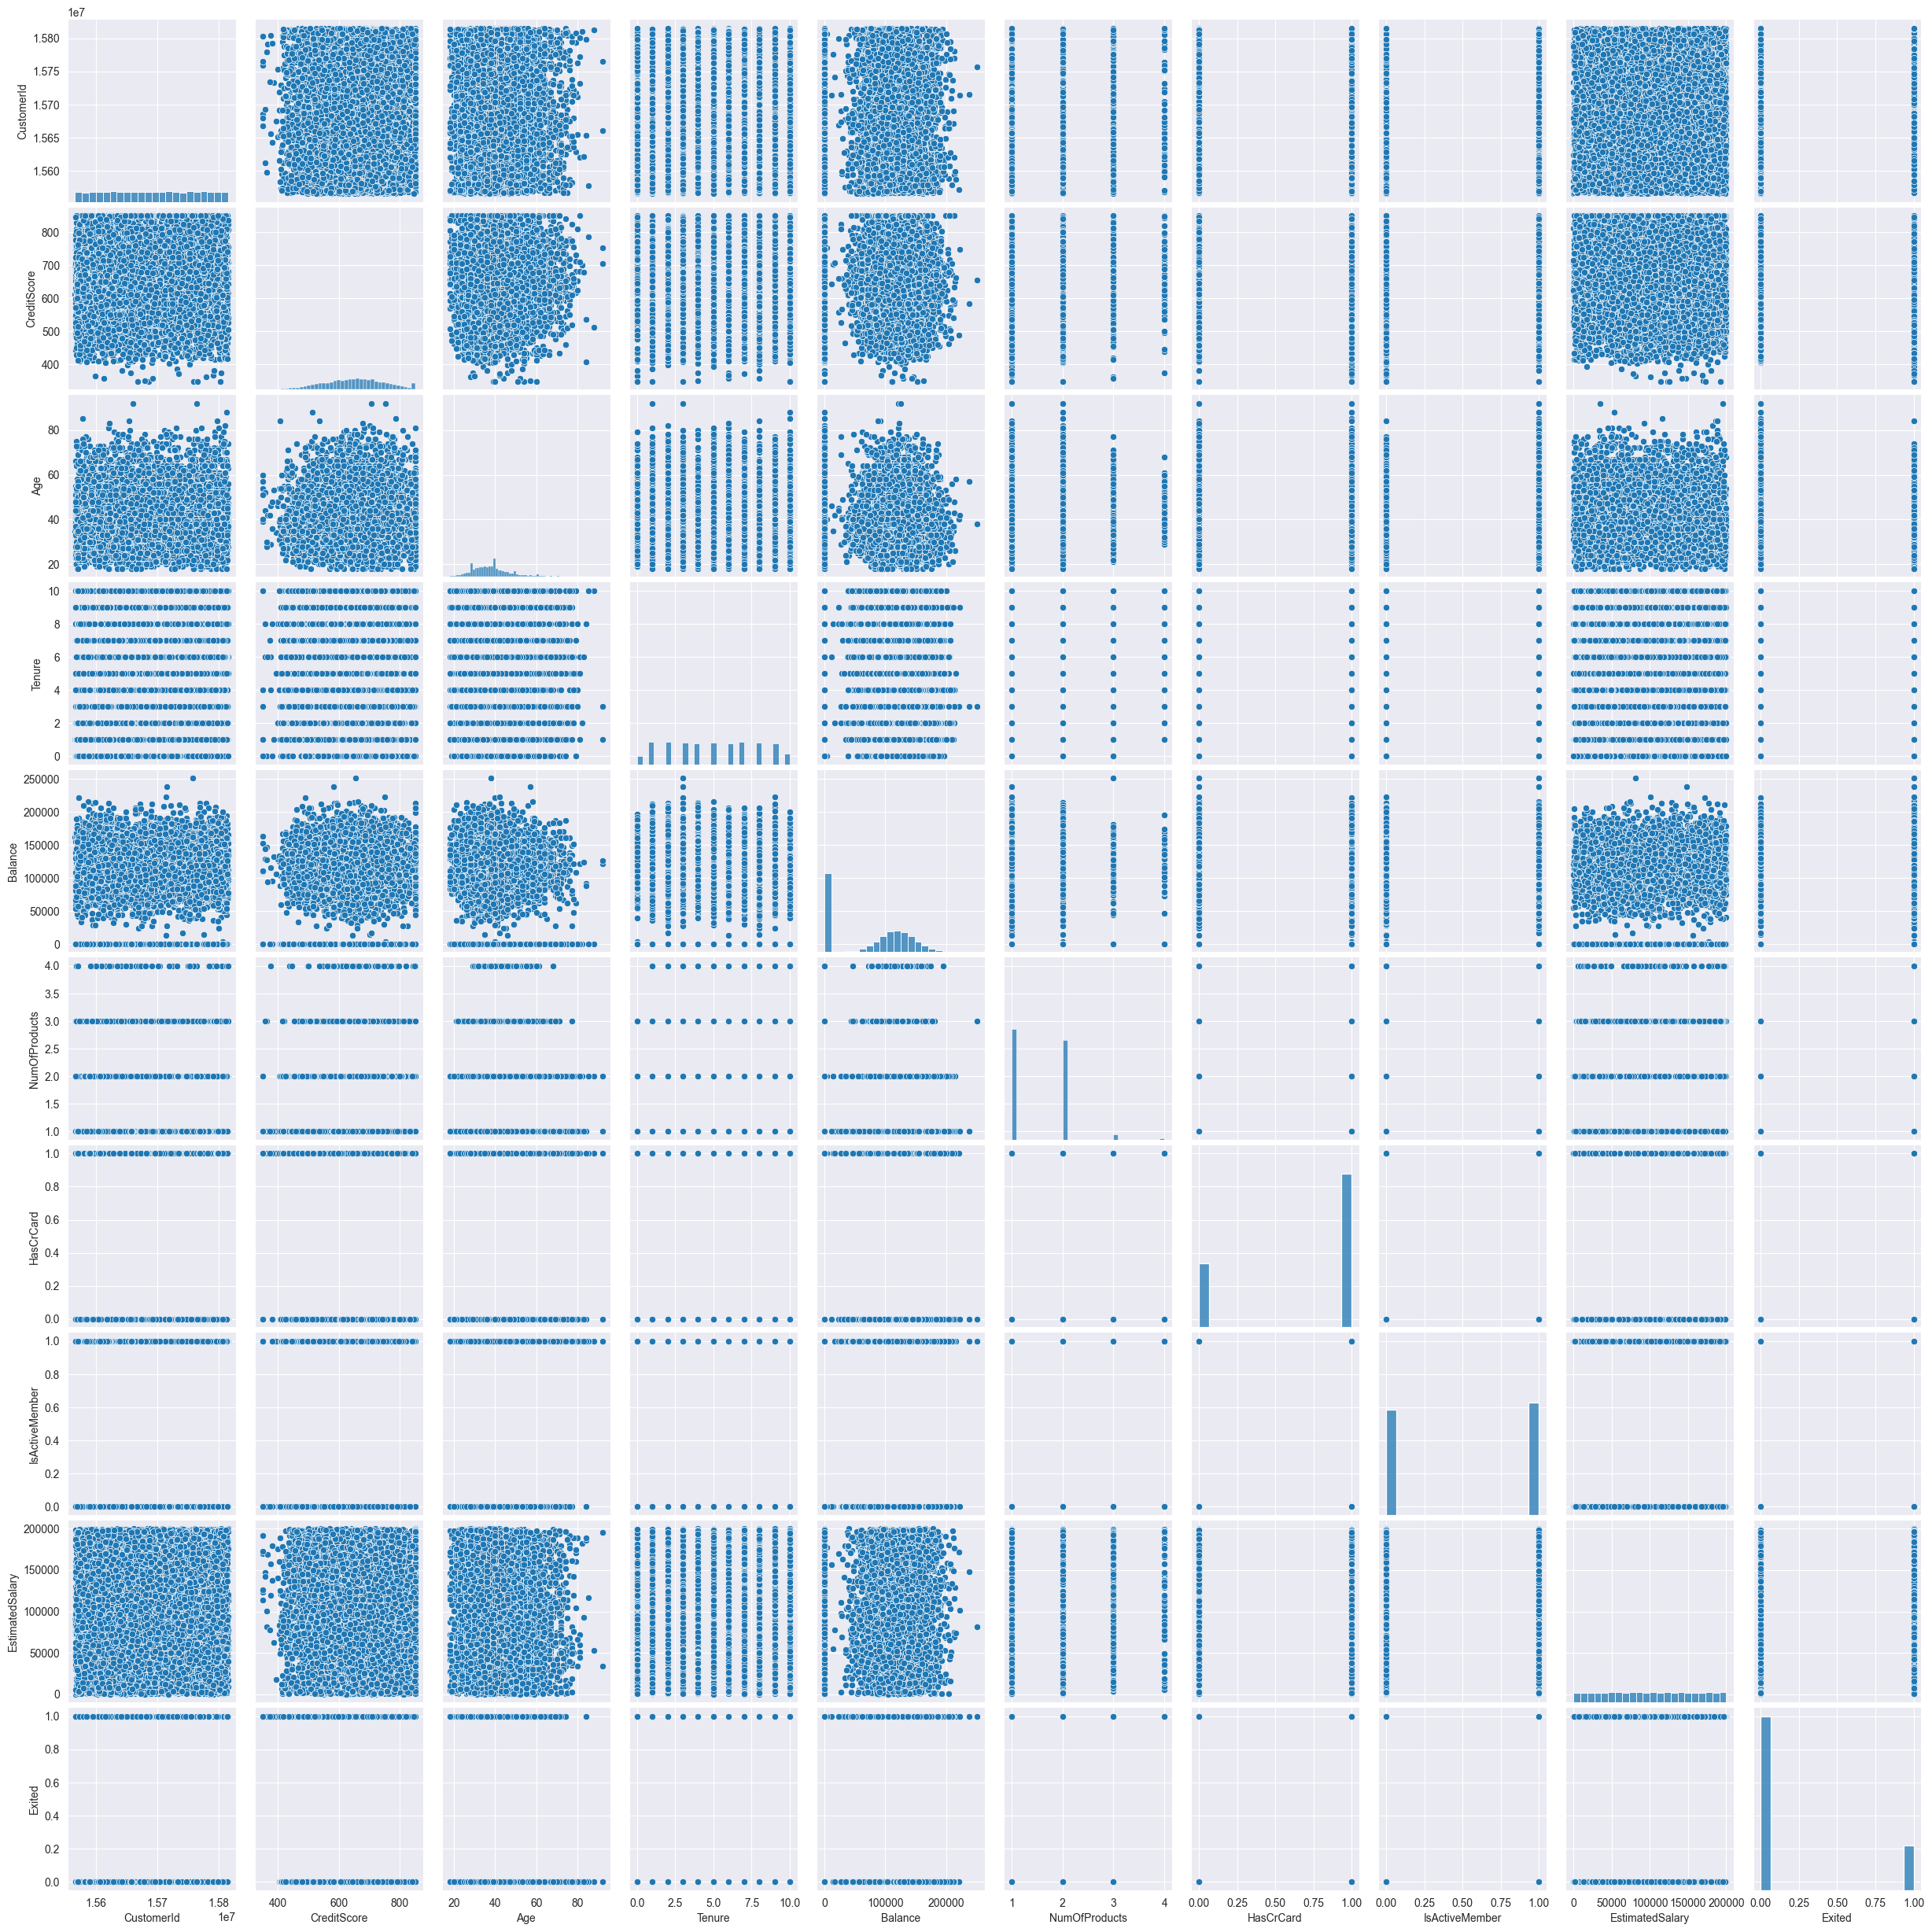

In [9]:
import seaborn as sns
sns.pairplot(churn)

<Axes: >

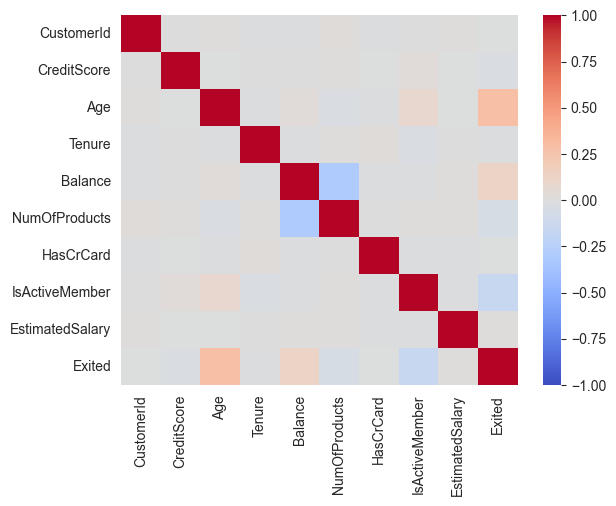

In [11]:
sns.heatmap(churn.corr(numeric_only=True),
            vmin=-1,
            vmax=1,
            cmap='coolwarm',

            )

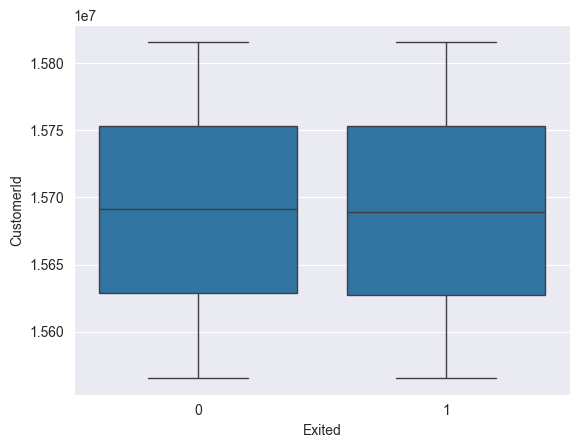

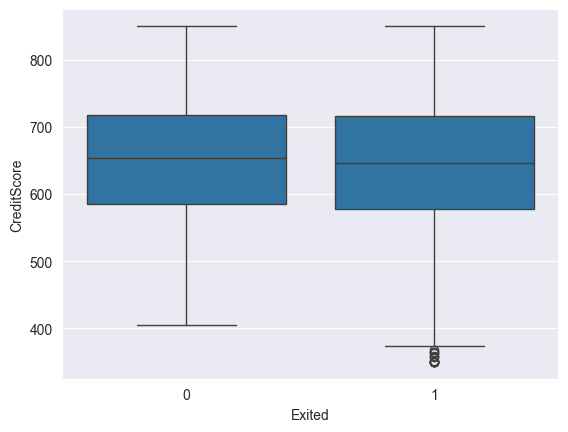

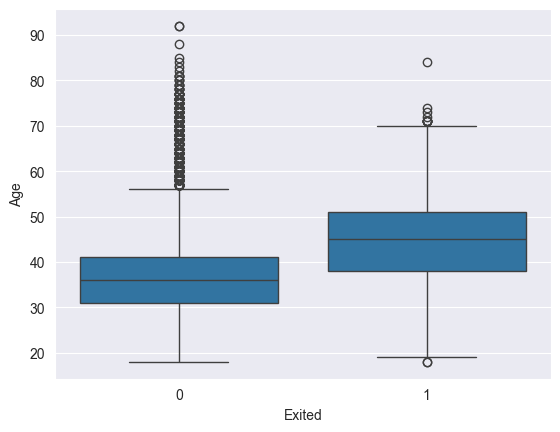

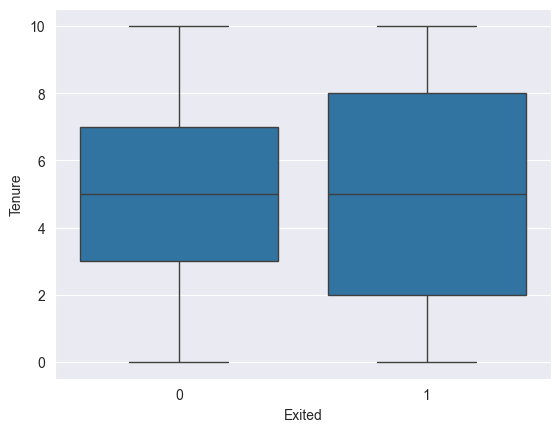

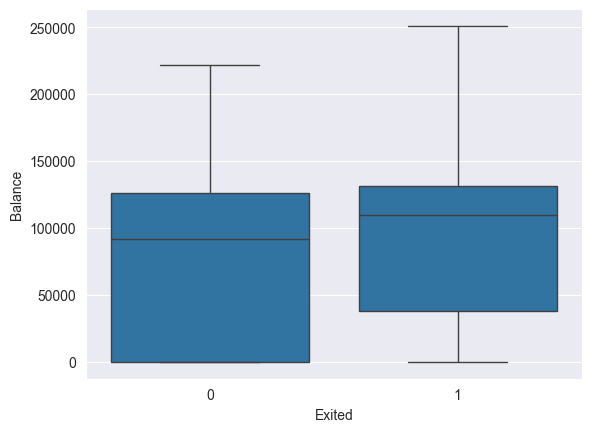

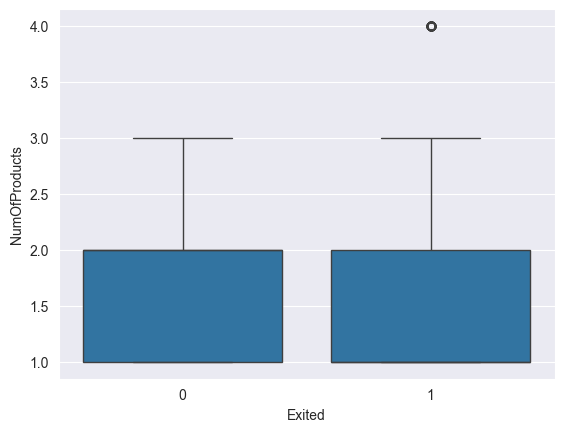

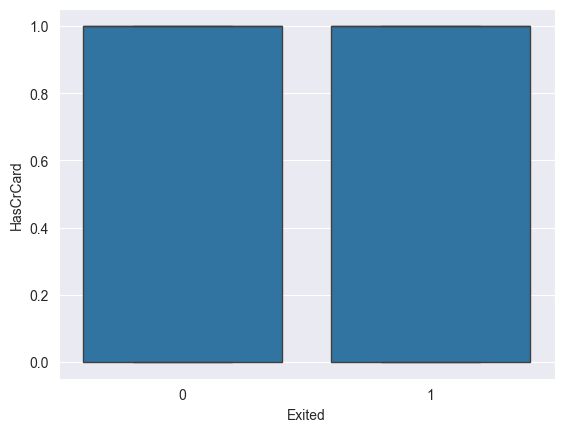

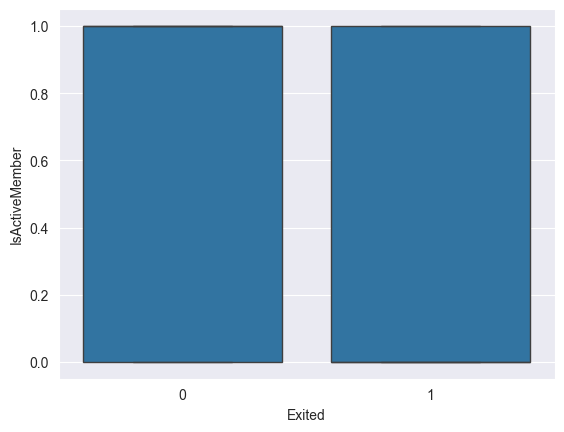

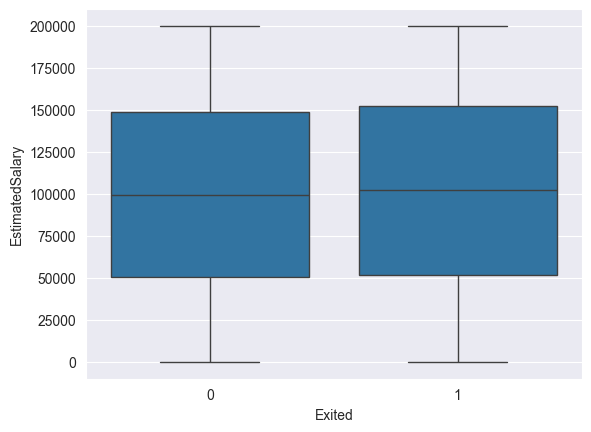

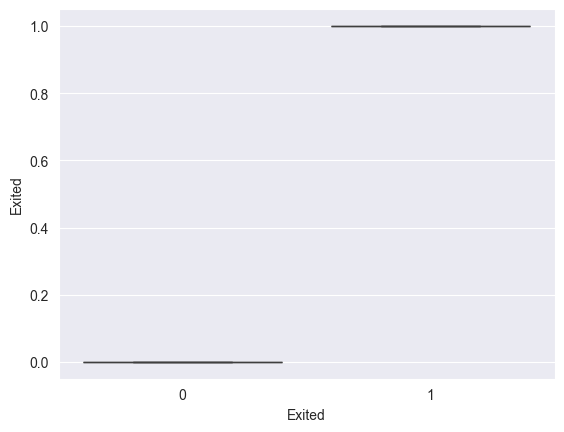

In [12]:
import matplotlib.pyplot as plt

for col in churn.select_dtypes("number"):
    sns.boxplot(data=churn, x="Exited", y=col)
    plt.show()

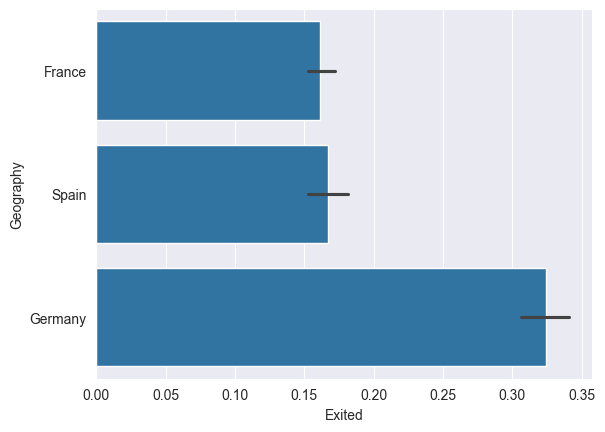

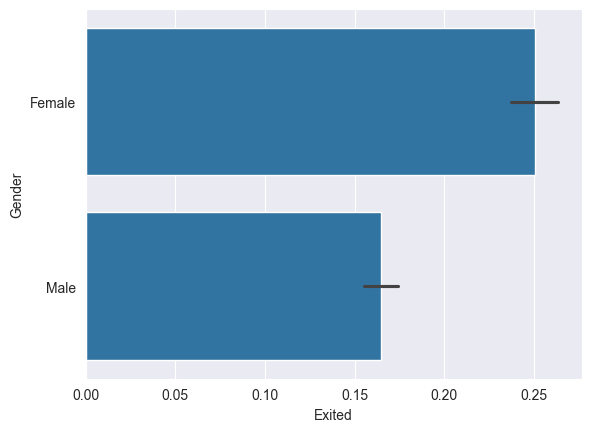

In [13]:
for col in churn.select_dtypes('object').columns[1:]:
    sns.barplot(data=churn, x="Exited", y=col)
    plt.show()

In [14]:
churn.select_dtypes('object').columns[1:]

Index(['Geography', 'Gender'], dtype='object')

## Data Modelling

In [15]:
churn_modelling_df = churn.drop(['CustomerId','Surname'], axis=1)

In [16]:
churn_modelling_df = churn_modelling_df.assign(
    balance_to_income = churn_modelling_df['Balance'] / churn_modelling_df['EstimatedSalary'],
    income_v_product = churn_modelling_df['EstimatedSalary'] / churn_modelling_df['NumOfProducts']
)

churn_modelling_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_product
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,101348.880
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677,112542.580
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375,37977.190
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,46913.315
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055,79084.100


In [17]:
churn_modelling_df.info()
churn_modelling_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Geography          10000 non-null  object 
 2   Gender             10000 non-null  object 
 3   Age                10000 non-null  int64  
 4   Tenure             10000 non-null  int64  
 5   Balance            10000 non-null  float64
 6   NumOfProducts      10000 non-null  int64  
 7   HasCrCard          10000 non-null  int64  
 8   IsActiveMember     10000 non-null  int64  
 9   EstimatedSalary    10000 non-null  float64
 10  Exited             10000 non-null  int64  
 11  balance_to_income  10000 non-null  float64
 12  income_v_product   10000 non-null  float64
dtypes: float64(4), int64(7), object(2)
memory usage: 1015.8+ KB


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_product
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,3.878703,74715.158001
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,108.337260,52058.899406
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,32589.780000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.747002,65908.002500
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.514022,100943.797500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,10614.655440,199970.740000


<Axes: xlabel='Exited', ylabel='balance_to_income'>

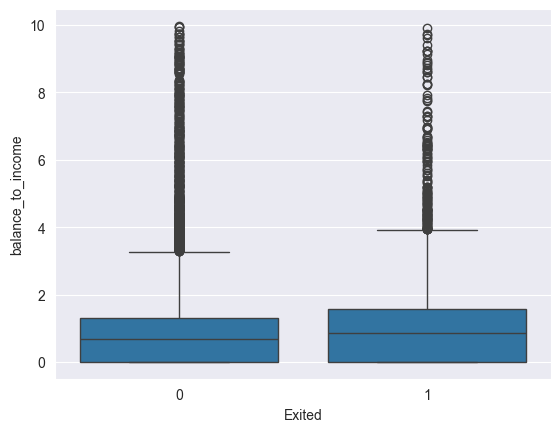

In [18]:
sns.boxplot(churn_modelling_df.query('balance_to_income < 10'),x = 'Exited', y = 'balance_to_income')

<Axes: xlabel='Exited', ylabel='income_v_product'>

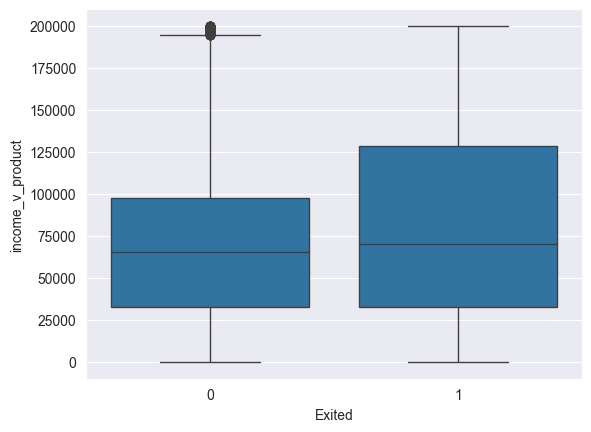

In [19]:
sns.boxplot(churn_modelling_df, x = 'Exited', y = 'income_v_product')

In [20]:
churn_modelling_df = pd.get_dummies(churn_modelling_df, drop_first = True)
churn_modelling_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_income,income_v_product,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,101348.880,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,112542.580,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,37977.190,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,46913.315,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587055,79084.100,False,True,False


In [21]:
from    sklearn.model_selection import train_test_split

X = churn_modelling_df.drop('Exited', axis=1)
y = churn_modelling_df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2024)

X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 8276 to 7816
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Tenure             8000 non-null   int64  
 3   Balance            8000 non-null   float64
 4   NumOfProducts      8000 non-null   int64  
 5   HasCrCard          8000 non-null   int64  
 6   IsActiveMember     8000 non-null   int64  
 7   EstimatedSalary    8000 non-null   float64
 8   balance_to_income  8000 non-null   float64
 9   income_v_product   8000 non-null   float64
 10  Geography_Germany  8000 non-null   bool   
 11  Geography_Spain    8000 non-null   bool   
 12  Gender_Male        8000 non-null   bool   
dtypes: bool(3), float64(4), int64(6)
memory usage: 710.9 KB


## Logistic Regression

In [50]:
X_train2 = X_train.drop(['Balance','EstimatedSalary', 'income_v_product'] ,axis=1)

In [22]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(solver = 'newton-cholesky' )

lr  = logreg.fit(X_train, y_train)

print(f"Training Accuracy: {lr.score(X_train, y_train)}")

Training Accuracy: 0.817


In [24]:
from sklearn.metrics import confusion_matrix,precision_score, recall_score, f1_score

confusion_matrix(y_train, lr.predict(X_train))

array([[6119,  253],
       [1211,  417]])

In [25]:
recall_score(y_train, lr.predict(X_train))

0.25614250614250617

In [67]:
list(zip(X_train, lr.coef_[0]))

[('CreditScore', np.float64(-0.0009187111129064385)),
 ('Age', np.float64(0.07348670677437194)),
 ('Tenure', np.float64(-0.01572307322158873)),
 ('Balance', np.float64(2.1594952278198648e-06)),
 ('NumOfProducts', np.float64(0.7986881910560673)),
 ('HasCrCard', np.float64(-0.11739952340062873)),
 ('IsActiveMember', np.float64(-1.0796835443611243)),
 ('EstimatedSalary', np.float64(-1.715376460983057e-05)),
 ('balance_to_income', np.float64(0.0005748891887945851)),
 ('income_v_product', np.float64(2.221317994433681e-05)),
 ('Geography_Germany', np.float64(0.7955740153693514)),
 ('Geography_Spain', np.float64(0.03551308451564065)),
 ('Gender_Male', np.float64(-0.4993144026831346))]

In [26]:
confusion_matrix(y_test, lr.predict(X_test))

array([[1536,   55],
       [ 320,   89]])

In [27]:
from sklearn.metrics import roc_curve, auc

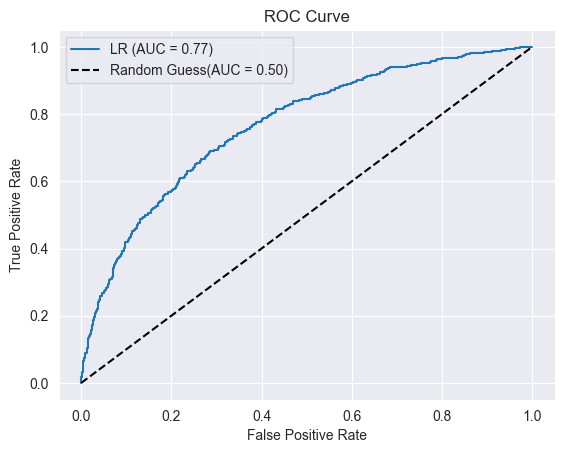

In [29]:
y_probs = lr.predict_proba(X_test)[:,1]
fpr1, tpr1, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr1, tpr1)

plt.plot(fpr1, tpr1, label = f'LR (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--',label = 'Random Guess(AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


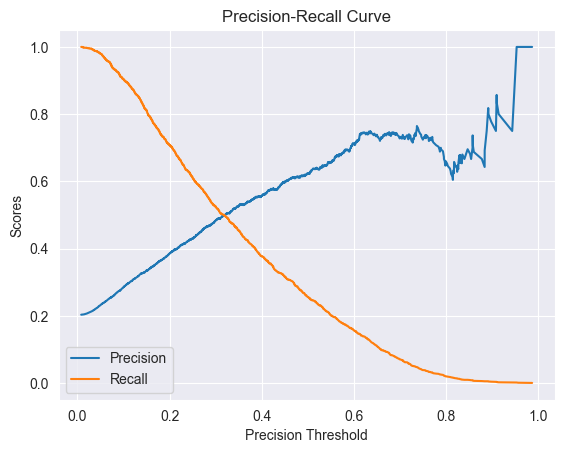

In [30]:
from sklearn.metrics import precision_recall_curve

p_curve, r_curve , t_curve = precision_recall_curve(y_train,lr.predict_proba(X_train)[:,1])

plt.plot(t_curve, p_curve[:-1], label = 'Precision')
plt.plot(t_curve, r_curve[:-1], label = 'Recall')


plt.xlabel('Precision Threshold')
plt.ylabel('Scores')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()



In [31]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,balance_to_income,income_v_product,Geography_Germany,Geography_Spain,Gender_Male
8276,580,32,9,142188.20,2,0,1,128028.60,1.110597,64014.300,False,True,True
9288,635,36,9,81231.85,2,1,0,196731.08,0.412908,98365.540,True,False,False
530,519,57,2,119035.35,2,1,1,29871.79,3.984875,14935.895,False,True,False
8127,651,35,8,110067.71,1,1,0,127678.95,0.862066,127678.950,True,False,True
9903,606,36,10,0.00,2,0,1,155641.46,0.000000,77820.730,False,False,False


In [32]:
import numpy as np

np.where(p_curve > 0.5)


(array([6377, 6383, 6384, ..., 7998, 7999, 8000], shape=(1619,)),)

In [33]:
t_curve[6377]

np.float64(0.3197171449360372)

In [34]:
confusion_matrix(y_test, lr.predict_proba(X_test)[:,1]>0.32)

array([[1400,  191],
       [ 223,  186]])

## Random Forest Model

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf = RandomForestClassifier()
rf = rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Test Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 1.0
Test Accuracy: 0.8555


In [45]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=2023, n_jobs=-1)

params = {
    'n_estimators': np.arange(start=100, stop=1100, step=100),
    'max_features': [None, "sqrt"],
    'bootstrap': [True, False],
    'max_samples': [None, .3, .5, .9],
    'max_depth': np.arange(start=1, stop=11, step=1),
    'min_samples_leaf': [2, 5, 10, 20, 100],
}

grid = RandomizedSearchCV(
    rf,
    params,
    n_iter=100,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

KeyboardInterrupt: 

In [41]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': np.arange(start=850, stop=951, step=10),
    'max_samples': [None, .4, .5, .6],
    'max_depth': np.arange(8, 10, 12),
    'min_samples_leaf': [5, 10, 15],
}

grid = GridSearchCV(
    rf,
    params,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': np.int64(8),
 'max_samples': None,
 'min_samples_leaf': 5,
 'n_estimators': np.int64(940)}

In [47]:
rf = RandomForestClassifier(**{'n_estimators': 680,
                               'max_features': None,
                               'max_depth': 8,
                               'min_samples_leaf': 5,
                               'max_samples': None,
                               'bootstrap': True
                               })

rf = rf.fit(X_train, y_train)

print(f"Training Accuracy: {rf.score(X_train, y_train)}")
print(f"Test Accuracy: {rf.score(X_test, y_test)}")

Training Accuracy: 0.886
Test Accuracy: 0.857


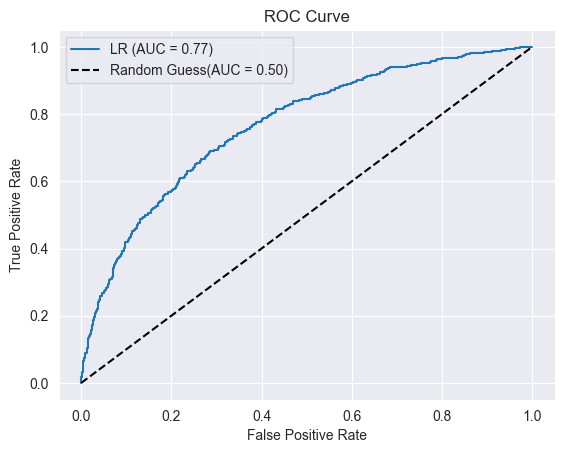

In [48]:
y_probs = lr.predict_proba(X_test)[:,1]
fpr1, tpr1, thresholds = roc_curve(y_test, y_probs)
auc_score = auc(fpr1, tpr1)

plt.plot(fpr1, tpr1, label = f'LR (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--',label = 'Random Guess(AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

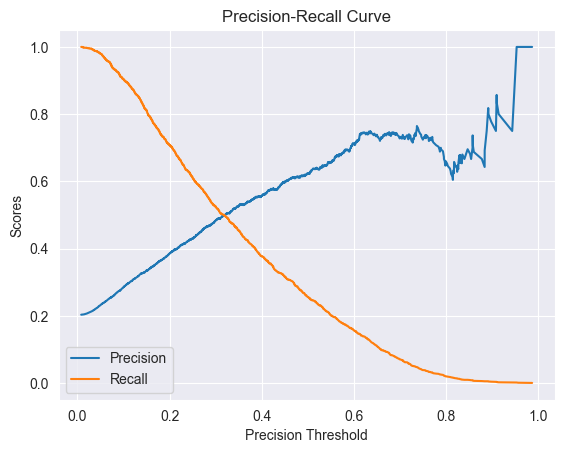

np.float64(0.766118708689926)

In [50]:
from sklearn.metrics import precision_recall_curve

p_curve, r_curve , t_curve = precision_recall_curve(y_train,lr.predict_proba(X_train)[:,1])

plt.plot(t_curve, p_curve[:-1], label = 'Precision')
plt.plot(t_curve, r_curve[:-1], label = 'Recall')


plt.xlabel('Precision Threshold')
plt.ylabel('Scores')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

auc_score

<Axes: xlabel='importance', ylabel='feature'>

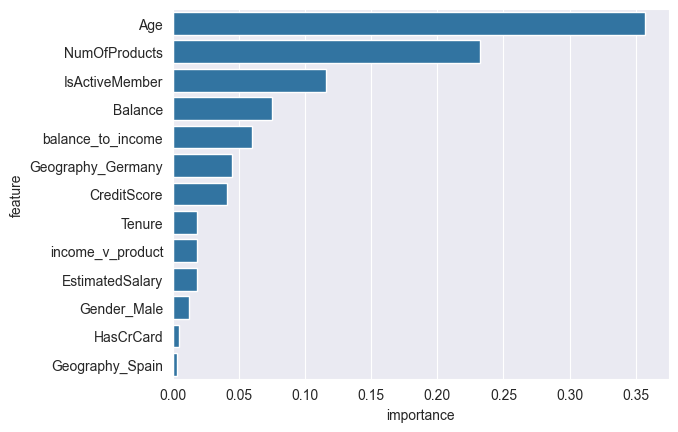

In [51]:
importance = pd.DataFrame(
    {'feature':X_train.columns,
     "importance": rf.feature_importances_}
    ).sort_values('importance', ascending=False).iloc[:20]

sns.barplot(importance, x="importance", y="feature")